# 01. EDA + первичная предобработка + первичные признаки для анализа

В этом ноутбуке проводится исследовательский анализ сигналов сцинтилляционного детектора.

Шаги этапа:
- корректно загружаем исходный txt-файл;
- изучаем структуру данных;
- готовим физически осмысленные признаки для дальнейшей кластеризации.


## 1. Подготовка окружения

**1.1.Импорт библиотек**

In [ ]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")

**1.2. Константы и пути к данным**

In [ ]:
RANDOM_STATE = 42
BASELINE_WINDOW = 50

PROJECT_DIR = Path(".")
DATA_DIR = PROJECT_DIR / "data"

DATA_PATH = DATA_DIR / "Run200_Wave_0_1.txt"

**1.3. Проверка пути к данным**

In [ ]:
# Проверка папки data и исходного файла

if DATA_DIR.exists():
    print("Папка data уже существует.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print("Папка data не найдена, поэтому была создана.")

print()
print("Путь к папке data:")
print(DATA_DIR.resolve())

print()
print("Файлы в папке data:")
data_files = sorted(DATA_DIR.glob("*"))

if data_files:
    for file_path in data_files:
        print(f"- {file_path.name}")
else:
    print("Папка data пока пустая.")

print()
print("Ожидаемый путь к исходному файлу:")
print(DATA_PATH)

print()
print(f"Файл найден: {DATA_PATH.exists()}")

Папка data уже существует.

Путь к папке data:
/content/data

Файлы в папке data:
- Run200_Wave_0_1.txt
- processed
- raw

Ожидаемый путь к исходному файлу:
data/Run200_Wave_0_1.txt

Файл найден: True


## 2. Загрузка данных

**Чтение исходного txt-файла**

In [ ]:
raw_data = pd.read_csv(
    DATA_PATH,
    sep=r"\s+",
    header=None,
)

print(f"Размер исходной таблицы: {raw_data.shape}")
print()
print("Первые 5 строк исходных данных:")
display(raw_data.head())

print()
print("Последние 5 колонок:")
display(raw_data.iloc[:, -5:].head())

Размер исходной таблицы: (23479, 504)

Первые 5 строк исходных данных:


,0,1,2,3,4,5,6,7,8,9,...,494,495,496,497,498,499,500,501,502,503
0,2890276,357,113,500,14820,14823,14824,14822,14818,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,4928764,740,359,500,14820,14822,14820,14826,14824,14822,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,9630204,162,499,500,14820,14820,14822,14825,14820,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,15798632,841,123,500,14828,14822,14818,14824,14824,14822,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,20637296,412,348,500,14823,14815,14823,14821,14827,14820,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825



Последние 5 колонок:


,499,500,501,502,503
0,14819,14820,14822,14820,14819
1,14819,14820,14819,14822,14820
2,14821,14823,14820,14820,14821
3,14828,14820,14822,14823,14822
4,14820,14824,14824,14822,14825


## 3. Первичный EDA исходных данных

**3.1. Разделение данных на метаданные и временные отсчёты сигнала**

Исходная таблица содержит 23 479 строк и 504 колонки.

Согласно описанию предметной области  в приложенном pdf-файле, первые 4 значения в каждой строке являются служебными метаданными, связанными с состоянием фотоэлектронного умножителя и параметрами регистрации. Остальные 500 значений представляют собой временные отсчёты зарегистрированного сигнала.

Поэтому далее данные разделяются на две части:

- `metadata` — первые 4 служебные колонки;
- `signals` — 500 временных отсчётов сигнала.

In [ ]:
metadata = raw_data.iloc[:, :4].copy()
signals = raw_data.iloc[:, 4:].copy()

metadata.columns = ["meta_0", "meta_1", "meta_2", "signal_length"]

signals.columns = [f"t_{i}" for i in range(signals.shape[1])]

print(f"Размер metadata: {metadata.shape}")
print(f"Размер signals: {signals.shape}")

print()
print("Первые строки metadata:")
display(metadata.head())

print()
print("Первые строки signals:")
display(signals.head())

Размер metadata: (23479, 4)
Размер signals: (23479, 500)

Первые строки metadata:


,meta_0,meta_1,meta_2,signal_length
0,2890276,357,113,500
1,4928764,740,359,500
2,9630204,162,499,500
3,15798632,841,123,500
4,20637296,412,348,500



Первые строки signals:


,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_490,t_491,t_492,t_493,t_494,t_495,t_496,t_497,t_498,t_499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


Произведено разделение исходного массива данных на два изолированных признаковых подпространства. Выделена матрица метаданных фотоэлектронного умножителя (ФЭУ) размерностью 23 479 строк на 4 столбца, а также чистая матрица сырых осциллограмм сигналов фиксированной длины (23 479 строк на 500 временных тактов).

**3.2. Проверка типов данных, пропусков и диапазона значений**

In [ ]:
# Проверка типов, пропусков и базовых свойств
print("Типы данных в metadata:")
display(metadata.dtypes)

print()
print("Типы данных в signals:")
print(signals.dtypes.value_counts())

print()
print("Количество пропусков:")
print(f"metadata: {metadata.isna().sum().sum()}")
print(f"signals: {signals.isna().sum().sum()}")

print()
print("Общий диапазон значений в signals:")
print(f"Минимум: {signals.min().min()}")
print(f"Максимум: {signals.max().max()}")

print()
print("Проверка длины сигнала из metadata:")
display(metadata["signal_length"].value_counts().head(10))

Типы данных в metadata:


,0
meta_0,int64
meta_1,int64
meta_2,int64
signal_length,int64



Типы данных в signals:
int64    500
Name: count, dtype: int64

Количество пропусков:
metadata: 0
signals: 0

Общий диапазон значений в signals:
Минимум: 0
Максимум: 14838

Проверка длины сигнала из metadata:


,count
signal_length,
500,23479


**3.3.Анализ служебных колонок**

In [ ]:
print("Первые строки metadata:")
display(metadata.head())

print()
print("Базовая статистика metadata:")
display(metadata.describe().T)

print()
print("Количество уникальных значений в metadata:")
display(metadata.nunique().to_frame("n_unique"))

print()
print("Топ значений по каждой metadata-колонке:")
for column in metadata.columns:
    print(f"\n{column}:")
    display(metadata[column].value_counts().head(10))

Первые строки metadata:


,meta_0,meta_1,meta_2,signal_length
0,2890276,357,113,500
1,4928764,740,359,500
2,9630204,162,499,500
3,15798632,841,123,500
4,20637296,412,348,500



Базовая статистика metadata:


,count,mean,std,min,25%,50%,75%,max
meta_0,23479.0,1.009742e+11,5.715472e+10,2890276.0,5.156311e+10,1.014553e+11,1.502418e+11,2.000107e+11
meta_1,23479.0,8.691600e+02,5.729058e+02,0.0,3.730000e+02,8.100000e+02,1.341000e+03,1.998000e+03
meta_2,23479.0,3.721917e+02,4.703917e+02,10.0,6.400000e+01,1.720000e+02,4.830000e+02,3.370000e+03
signal_length,23479.0,5.000000e+02,0.000000e+00,500.0,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02



Количество уникальных значений в metadata:


...

,count
meta_1,
0,293
1810,194
1185,187
1341,184
1498,182
1748,176
1935,173
498,172
1154,172



meta_2:


,count
meta_2,
30,160
29,159
24,159
23,158
26,157
33,146
21,144
35,143
32,143



signal_length:


,count
signal_length,
500,23479


### **Выводы по первичному EDA**

Первые четыре колонки были отделены от временного ряда как служебные признаки. Это согласуется с описанием данных: после 4 служебных значений в каждой строке идут 500 отсчётов зарегистрированного сигнала.

Проверка показала, что:

- все metadata-колонки имеют числовой тип;
- пропусков в metadata нет;
- колонка `signal_length` принимает одно и то же значение `500` для всех 23 479 объектов;
- остальные metadata-колонки содержат повторяющиеся технические значения.

Так как основная цель задачи — разделить сигналы по форме импульса, дальнейший EDA будет проводиться по матрице `signals`, содержащей 500 временных отсчётов. Metadata сохраняются отдельно и используются только для проверки структуры данных.

## 4. EDA формы сырых сигналов

**4.1.Визуализация случайных сырых сигналов**

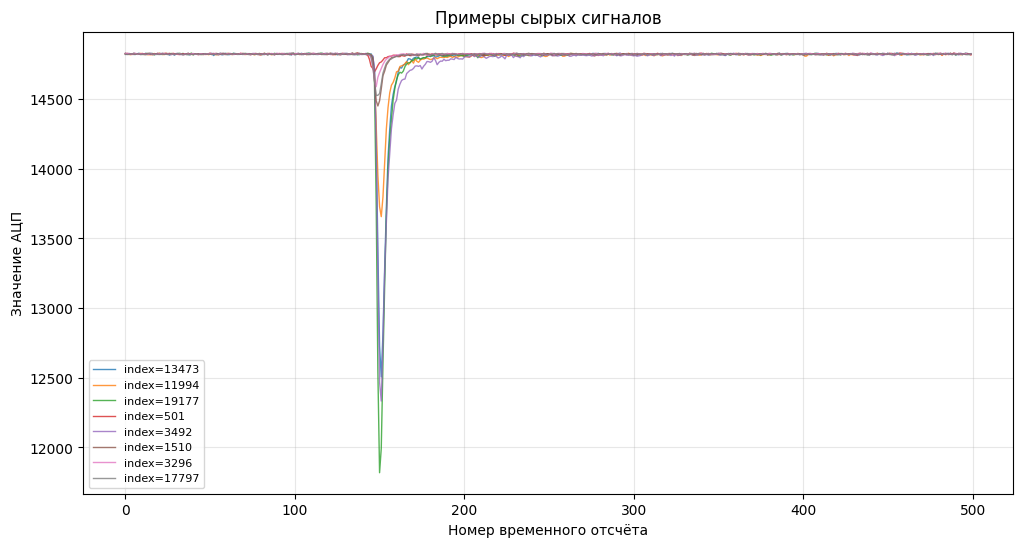

In [ ]:
# Визуализация нескольких случайных сырых сигналов

sample_indices = signals.sample(
    n=8,
    random_state=RANDOM_STATE,
).index

plt.figure(figsize=(12, 6))

for index in sample_indices:
    plt.plot(
        signals.loc[index].values,
        linewidth=1,
        alpha=0.8,
        label=f"index={index}",
    )

plt.title("Примеры сырых сигналов")
plt.xlabel("Номер временного отсчёта")
plt.ylabel("Значение АЦП")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.show()

 **Вывод по первичной визуализации сырых сигналов**

На графике показаны несколько случайно выбранных сырых сигналов. Видно, что большая часть временного ряда находится около почти постоянного базового уровня, а сам импульс проявляется как резкий отрицательный провал.

После провала сигнал постепенно возвращается к базовой линии. Именно форма этого восстановления, то есть хвост импульса, потенциально содержит информацию для разделения сигналов разных типов.

Перед baseline-коррекцией и построением признаков необходимо проверить положение импульса по всем объектам: для этого далее будет рассчитано распределение индекса минимального значения сигнала.

**4.2. Проверка положения основного импульса**

Статистика индекса минимального значения сигнала:
count    23479.000000
mean       149.628604
std          2.489996
min        145.000000
25%        149.000000
50%        150.000000
75%        151.000000
max        472.000000
dtype: float64


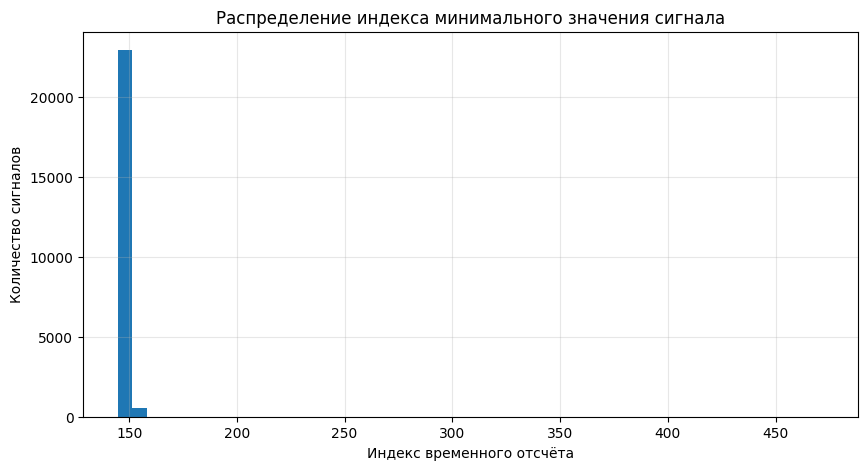

In [ ]:
# Распределение положения импульса в сырых сигналах

min_indices = signals.values.argmin(axis=1)

print("Статистика индекса минимального значения сигнала:")
print(pd.Series(min_indices).describe())

plt.figure(figsize=(10, 5))
plt.hist(min_indices, bins=50)
plt.title("Распределение индекса минимального значения сигнала")
plt.xlabel("Индекс временного отсчёта")
plt.ylabel("Количество сигналов")
plt.grid(alpha=0.3)
plt.show()

**Вывод по положению импульса**

Для каждого сигнала был найден индекс минимального значения, так как в сырых данных импульс направлен вниз. Распределение индексов минимума показывает, что основной провал сигнала почти всегда расположен в узкой области временного ряда, примерно около 150-го отсчёта.

Это подтверждает, что сигналы синхронизированы по времени. Следовательно, первые отсчёты временного ряда можно использовать для оценки базовой линии и шума, а признаки формы сигнала целесообразно строить относительно положения основного импульса.

**4.3 Проверка нетипичных сигналов по положению импульса**

Граница 1%: 146
Граница 99%: 152
Количество нетипичных сигналов по положению минимума: 39
Доля нетипичных сигналов: 0.17%

Примеры индексов нетипичных сигналов:
[809, 1369, 1891, 1929, 2321, 3980, 4193, 4710, 4953, 5184]


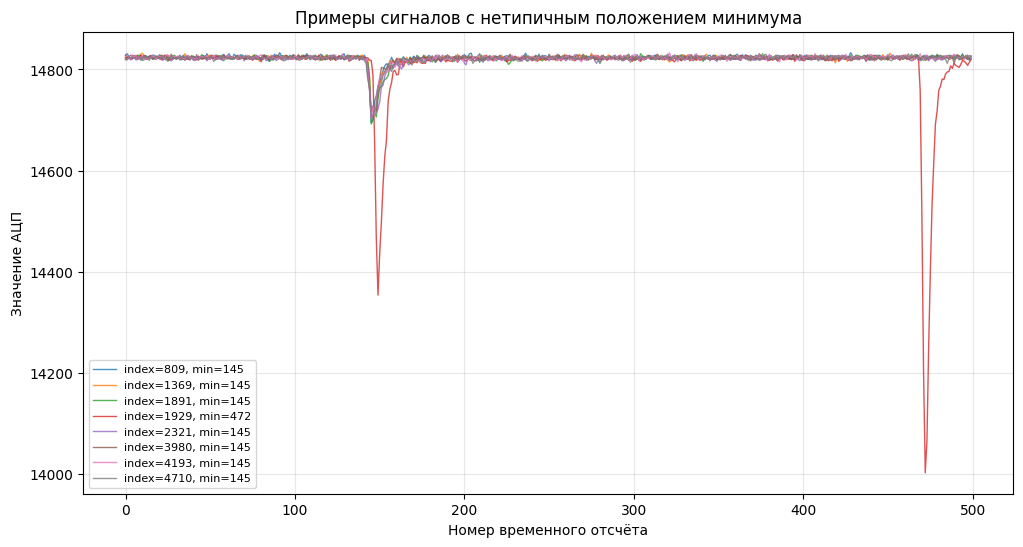

In [ ]:
# Проверка сигналов, у которых минимум расположен вне основной области импульса

min_indices_series = pd.Series(min_indices, name="min_index")

typical_min_left = min_indices_series.quantile(0.01)
typical_min_right = min_indices_series.quantile(0.99)

atypical_mask = (
    (min_indices_series < typical_min_left)
    | (min_indices_series > typical_min_right)
)

atypical_indices = min_indices_series[atypical_mask].index

print(f"Граница 1%: {typical_min_left:.0f}")
print(f"Граница 99%: {typical_min_right:.0f}")
print(f"Количество нетипичных сигналов по положению минимума: {len(atypical_indices)}")
print(f"Доля нетипичных сигналов: {len(atypical_indices) / len(signals):.2%}")

print()
print("Примеры индексов нетипичных сигналов:")
print(list(atypical_indices[:10]))

plt.figure(figsize=(12, 6))

for index in atypical_indices[:8]:
    plt.plot(
        signals.loc[index].values,
        linewidth=1,
        alpha=0.8,
        label=f"index={index}, min={min_indices[index]}",
    )

plt.title("Примеры сигналов с нетипичным положением минимума")
plt.xlabel("Номер временного отсчёта")
plt.ylabel("Значение АЦП")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.show()

**Вывод по нетипичному положению импульса**

Для проверки возможных аномалий было проанализировано положение минимального значения в каждом сыром сигнале. Основная масса сигналов имеет минимум в узком диапазоне примерно от 146-го до 152-го отсчёта.

По квантильному правилу 1%–99% найдено 39 сигналов с нетипичным положением минимума, что составляет около 0.17% выборки. На графике видно, что часть таких сигналов действительно имеет основной провал вне типичной области, например ближе к концу временного ряда.

Такие объекты не удаляются на этапе EDA, так как по условию задачи третий кластер может соответствовать аномальным или неоднозначным сигналам. Однако этот результат важно учитывать на следующих этапах: признаки положения импульса и признаки формы хвоста могут помочь выделить нетипичные сигналы в отдельную группу.

## 5. Предобработка данных

**5.1. Оценка базовой линии сигнала**



Статистика baseline_mean:


,baseline_mean
count,23479.000000
mean,14822.966507
std,0.856405
min,14818.920000
25%,14822.380000
50%,14822.960000
75%,14823.540000
max,14826.480000



Статистика baseline_std:


,baseline_std
count,23479.000000
mean,2.707879
std,0.267253
min,1.690429
25%,2.526916
50%,2.701776
75%,2.883026
max,3.791774


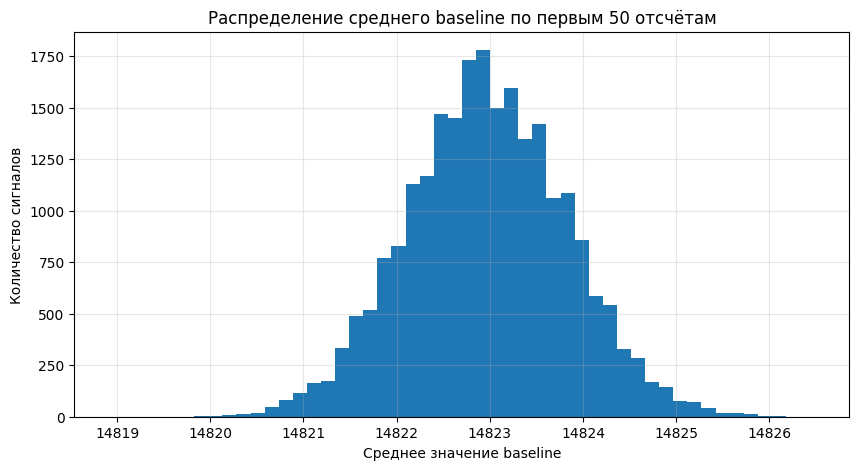

In [ ]:
# Расчёт baseline по первым 50 отсчётам

baseline_part = signals.iloc[:, :BASELINE_WINDOW]

baseline_mean = baseline_part.mean(axis=1)
baseline_std = baseline_part.std(axis=1)

baseline_stats = pd.DataFrame(
    {
        "baseline_mean": baseline_mean,
        "baseline_std": baseline_std,
    }
)

print("Статистика baseline_mean:")
display(baseline_stats["baseline_mean"].describe())

print()
print("Статистика baseline_std:")
display(baseline_stats["baseline_std"].describe())

plt.figure(figsize=(10, 5))
plt.hist(baseline_mean, bins=50)
plt.title("Распределение среднего baseline по первым 50 отсчётам")
plt.xlabel("Среднее значение baseline")
plt.ylabel("Количество сигналов")
plt.grid(alpha=0.3)
plt.show()

**Вывод по базовой линии**

Для оценки базовой линии был использован левый участок сигнала — первые 50 отсчётов. Такой выбор согласуется с теоретическим описанием, где нулевая линия определяется как среднее значение в левом хвосте кривой.

Распределение `baseline_mean` сосредоточено около значения 14823, а стандартное отклонение baseline небольшое: среднее значение `baseline_std` составляет около 2.71. Это показывает, что до появления импульса сигнал находится около стабильного базового уровня, а шум на начальном участке относительно мал.

Следовательно, первые 50 отсчётов можно использовать для baseline-коррекции: из каждого сигнала будет вычитаться индивидуальный уровень базовой линии.

**5.2. Baseline-коррекция и инверсия сигналов**

In [ ]:
# Baseline-коррекция и инверсия сигналов

signals_centered = signals.sub(baseline_mean, axis=0)
signals_inverted = -signals_centered

print(f"Размер signals_centered: {signals_centered.shape}")
print(f"Размер signals_inverted: {signals_inverted.shape}")

print()
print("Диапазон значений после инверсии:")
print(f"Минимум: {signals_inverted.min().min():.2f}")
print(f"Максимум: {signals_inverted.max().max():.2f}")

print()
print("Первые строки signals_inverted:")
display(signals_inverted.head())

Размер signals_centered: (23479, 500)
Размер signals_inverted: (23479, 500)

Диапазон значений после инверсии:
Минимум: -15.60
Максимум: 14824.84

Первые строки signals_inverted:


,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_490,t_491,t_492,t_493,t_494,t_495,t_496,t_497,t_498,t_499
0,1.48,-1.52,-2.52,-0.52,3.48,1.48,-2.52,-0.52,1.48,1.48,...,-6.52,-0.52,6.48,6.48,4.48,2.48,1.48,-0.52,1.48,2.48
1,2.48,0.48,2.48,-3.52,-1.52,0.48,2.48,0.48,-0.52,1.48,...,-5.52,5.48,-1.52,0.48,-1.52,3.48,2.48,3.48,0.48,2.48
2,1.90,1.90,-0.10,-3.10,1.90,-2.10,-2.10,2.90,-1.10,-2.10,...,1.90,0.90,1.90,1.90,3.90,0.90,-1.10,1.90,1.90,0.90
3,-5.44,0.56,4.56,-1.44,-1.44,0.56,2.56,0.56,-1.44,2.56,...,-1.44,-3.44,0.56,1.56,2.56,-5.44,2.56,0.56,-0.44,0.56
4,-1.40,6.60,-1.40,0.60,-5.40,1.60,-1.40,-2.40,5.60,0.60,...,1.60,1.60,-1.40,-6.40,-2.40,1.60,-2.40,-2.40,-0.40,-3.40


**5.3 Визуализация обработанных сигналов**

**Вывод по baseline-коррекции и инверсии**

Для каждого сигнала была выполнена индивидуальная baseline-коррекция: из временного ряда вычиталось среднее значение первых 50 отсчётов. После этого сигнал был инвертирован, чтобы основной импульс был направлен вверх.

После преобразования размер матрицы не изменился и остался равным `23479 × 500`. Значения около нуля теперь соответствуют базовой линии и шуму, а положительные значения отражают величину импульса.

Такое представление удобнее для дальнейшего EDA: по нему можно интерпретируемо рассчитывать амплитуду, площадь под сигналом и признаки хвоста.

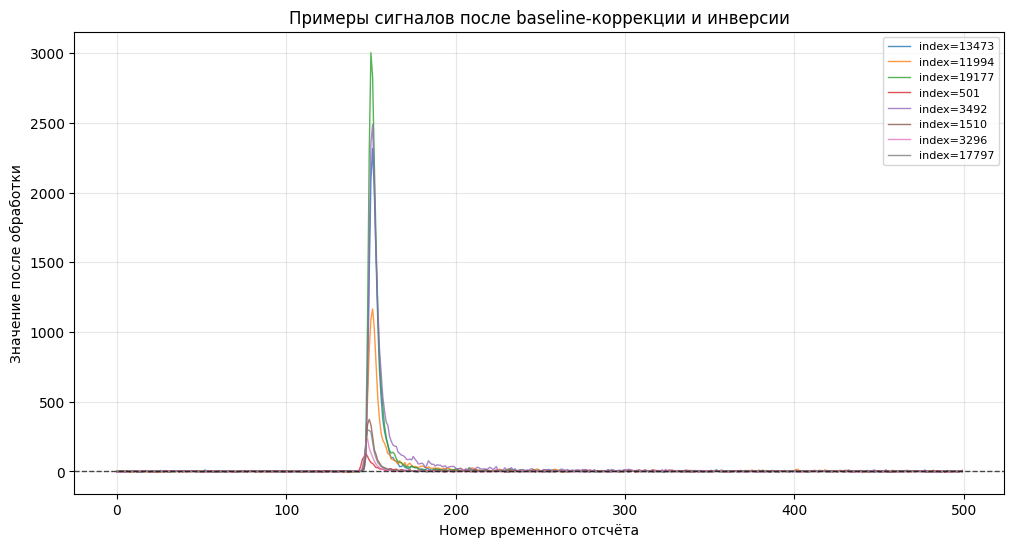

In [ ]:
# Визуализация сигналов после baseline-коррекции и инверсии

plt.figure(figsize=(12, 6))

for index in sample_indices:
    plt.plot(
        signals_inverted.loc[index].values,
        linewidth=1,
        alpha=0.8,
        label=f"index={index}",
    )

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    color="black",
    alpha=0.7,
)

plt.title("Примеры сигналов после baseline-коррекции и инверсии")
plt.xlabel("Номер временного отсчёта")
plt.ylabel("Значение после обработки")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.show()

**Вывод по визуализации обработанных сигналов**

После baseline-коррекции и инверсии базовая линия сигналов находится около нуля, а основной импульс направлен вверх. Это делает форму сигнала более удобной для дальнейшего анализа.

На графике видно, что сигналы отличаются по амплитуде и характеру спада после пика. Эти различия важны для дальнейшего построения физических признаков: амплитуды, площади под импульсом и характеристик хвоста.

## 6. Итоги первого ноутбука

В первом ноутбуке была выполнена загрузка и первичный анализ исходного txt-файла с сигналами.

Основные результаты:

- исходная таблица содержит `23 479` строк и `504` колонки;
- первые 4 колонки были отделены как служебные metadata-признаки;
- оставшиеся 500 колонок представляют собой временные отсчёты сигналов;
- пропусков в данных не обнаружено;
- все временные отсчёты имеют числовой тип;
- длина сигнала для всех объектов равна 500 отсчётам;
- сырые сигналы имеют почти постоянную базовую линию и основной импульс в виде отрицательного провала;
- основной импульс у большинства сигналов расположен в узкой области около 150-го отсчёта;
- найдено небольшое число сигналов с нетипичным положением минимума — около 0.17% выборки;
- базовая линия была рассчитана индивидуально для каждого сигнала как среднее первых 50 отсчётов;
- выполнены baseline-коррекция и инверсия сигналов, после чего импульсы стали направлены вверх, а базовая линия оказалась около нуля.

Таким образом, в первом ноутбуке были выполнены два этапа решения: исследование исходных данных и базовая предобработка сигналов. Дальнейшее построение признаков, анализ их информативности, сравнение моделей и подбор гиперпараметров будут вынесены во второй ноутбук.